## Imports

In [1]:
import sys
sys.path.append("../") # Allows importing from the root directory


from dataclasses import replace
from config import RLConfig
from agents import DQNAgent, DDQNAgent, DuelingDQNAgent, REINFORCEAgent
from trainer import ValueTrainer, PolicyTrainer
from utils import RLPlotter
import gymnasium as gym

## Experiments

### 1. Acrobot

>**Initializations**

In [2]:
# Shared environment setup
config = RLConfig(EPISODES=5000, STEP_BASED_TARGET_UPDATE_FREQ=5000)
env = gym.make_vec(config.ENV_NAME, num_envs=config.NUM_ENVS)

#### 1.1. DQN


Standard DQN on Acrobot

> Training Loop

In [ ]:
dqn_agent = DQNAgent(env.single_observation_space.shape[0], env.single_action_space.n, config)
dqn_trainer = ValueTrainer(env, dqn_agent, config)
dqn_rewards = dqn_trainer.train()
dqn_trainer.save_checkpoint(filepath="../models/checkpoints/Acrobot/dqn_checkpoint.pth")

Starting Vectorized DQN Training on Acrobot-v1...


  0%|          | 0/5000 [00:00<?, ?it/s]d:\Projects\RL Analytics\Notebooks\..\utils.py:29: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  return torch.tensor(states), torch.tensor(actions), torch.tensor(rewards), torch.tensor(next_states), torch.tensor(done)
100%|██████████| 5000/5000 [42:56<00:00,  1.94it/s] 

DQN Training completed!
Model successfully saved to models/checkpoints/Acrobot/dqn_checkpoint.pth


> Plots

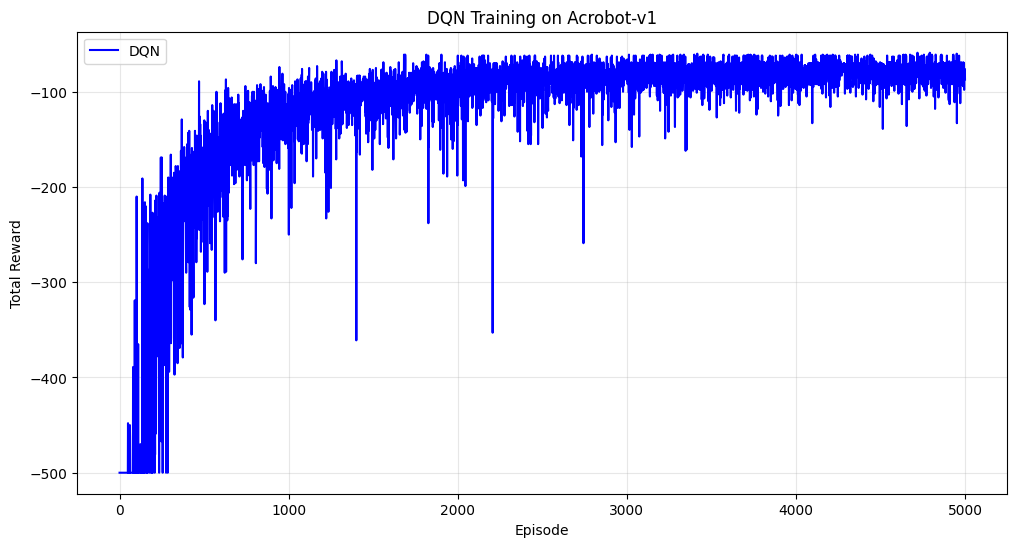

In [5]:
plot_dqn = RLPlotter(dqn_trainer.model_name, config.ENV_NAME, dqn_rewards)
plot_dqn.plot()

#### 1.2. DDQN


Standard DDQN on Acrobot

> Training

In [6]:
ddqn_agent = DDQNAgent(env.single_observation_space.shape[0], env.single_action_space.n, config)
ddqn_trainer = ValueTrainer(env, ddqn_agent, config)
ddqn_rewards = ddqn_trainer.train()
ddqn_trainer.save_checkpoint(filepath="../models/checkpoints/Acrobot/ddqn_checkpoint.pth")

Starting Vectorized DDQN Training on Acrobot-v1...


100%|██████████| 5000/5000 [56:59<00:00,  1.46it/s]  

DDQN Training completed!
Model successfully saved to models/checkpoints/Acrobot/ddqn_checkpoint.pth


> Plots

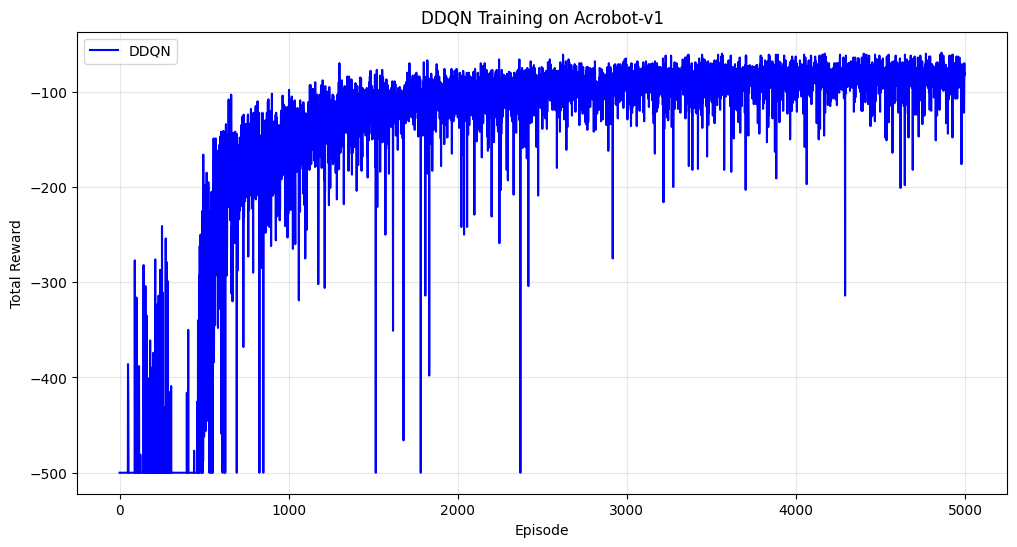

In [7]:
plot_ddqn = RLPlotter(ddqn_trainer.model_name, config.ENV_NAME, ddqn_rewards)
plot_ddqn.plot()

#### 1.3. Dueling DDQN


Two Implementations: Mean Normalized Advantage and Max Normalized Advantage


##### 1.3.1. Dueling DDQN with Mean Normalized Advantage

> Custom Initialization

In [11]:
dueling_config = replace(config, DUELING_OPT=0)

> Training

In [12]:
dueling_agent = DuelingDQNAgent(env.single_observation_space.shape[0], env.single_action_space.n, dueling_config)
dueling_trainer = ValueTrainer(env, dueling_agent, dueling_config)
dueling_rewards = dueling_trainer.train()
dueling_trainer.save_checkpoint(filepath="../models/checkpoints/Acrobot/dueling_mean_checkpoint.pth")

Starting Vectorized DuelingDQN Training on Acrobot-v1...


100%|██████████| 5000/5000 [1:03:30<00:00,  1.31it/s]

DuelingDQN Training completed!
Model successfully saved to ../models/checkpoints/Acrobot/dueling_mean_checkpoint.pth


> Plots

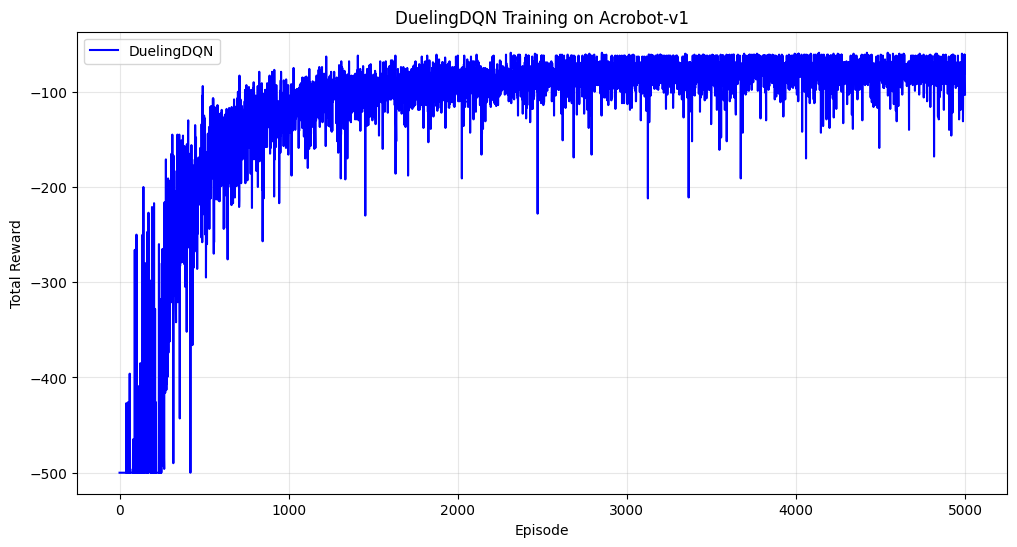

In [13]:
plot_dueling_mean = RLPlotter(dueling_trainer.model_name, dueling_config.ENV_NAME, dueling_rewards)
plot_dueling_mean.plot()

In [14]:
# Release the dueling config resources
del dueling_config

##### 1.3.2. Dueling DDQN with Max Normalized Advantage

> Custom Initialization

In [15]:
dueling_config = replace(config, DUELING_OPT=1)

> Training

In [16]:
dueling_agent = DuelingDQNAgent(env.single_observation_space.shape[0], env.single_action_space.n, dueling_config)
dueling_trainer = ValueTrainer(env, dueling_agent, dueling_config)
dueling_rewards = dueling_trainer.train()
dueling_trainer.save_checkpoint(filepath="../models/checkpoints/Acrobot/dueling_max_checkpoint.pth")

Starting Vectorized DuelingDQN Training on Acrobot-v1...


100%|██████████| 5000/5000 [1:02:41<00:00,  1.33it/s]

DuelingDQN Training completed!
Model successfully saved to ../models/checkpoints/Acrobot/dueling_max_checkpoint.pth


> Plots

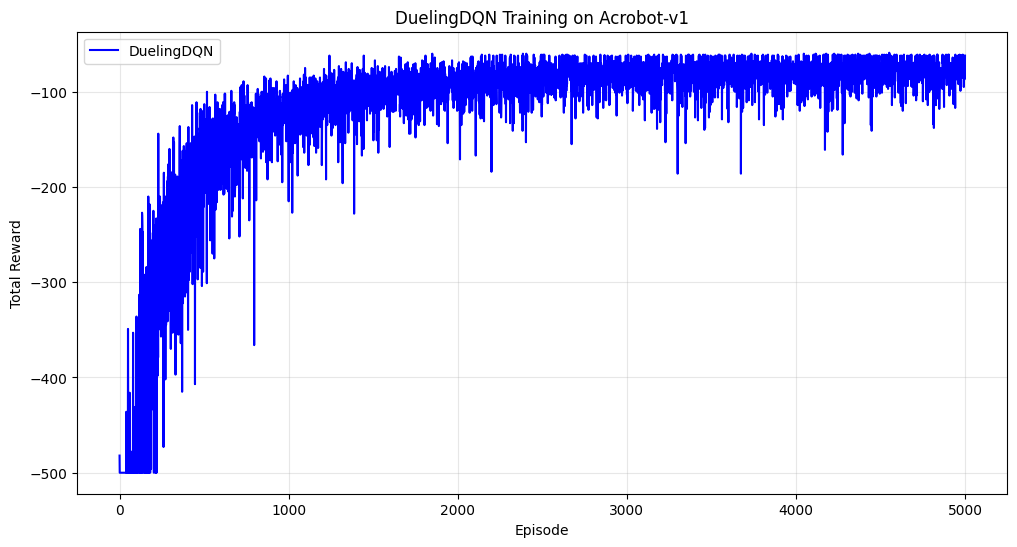

In [17]:
plot_dueling_max = RLPlotter(dueling_trainer.model_name, dueling_config.ENV_NAME, dueling_rewards)
plot_dueling_max.plot()

In [18]:
# Release the dueling config resources
del dueling_config

#### 1.4. Monte Carlo REINFORCE

Three Implementations:

1. No Baseline
2. Episodic Mean/std Normalized Baseline
3. Critic network baseline

##### 1.4.1. Monte Carlo REINFORCE with No Baseline

> Custom Initialization

In [15]:
montecarlo = replace(config, LEARNING_RATE=3e-4, MONTECARLO_BASELINE_OPT=0)

> Training

In [4]:
mcr_agent = REINFORCEAgent(env.single_observation_space.shape[0], env.single_action_space.n, montecarlo)
mcr_trainer = PolicyTrainer(env, mcr_agent, montecarlo)
mcr_rewards = mcr_trainer.train()
mcr_trainer.save_checkpoint(filepath="../models/checkpoints/Acrobot/mcr_noBase_checkpoint.pth")

Starting Vectorized REINFORCE Training on Acrobot-v1...


100%|██████████| 5000/5000 [07:09<00:00, 11.64it/s]

Policy-Based Training completed!
Model successfully saved to ../models/checkpoints/Acrobot/mcr_noBase_checkpoint.pth


> Plots

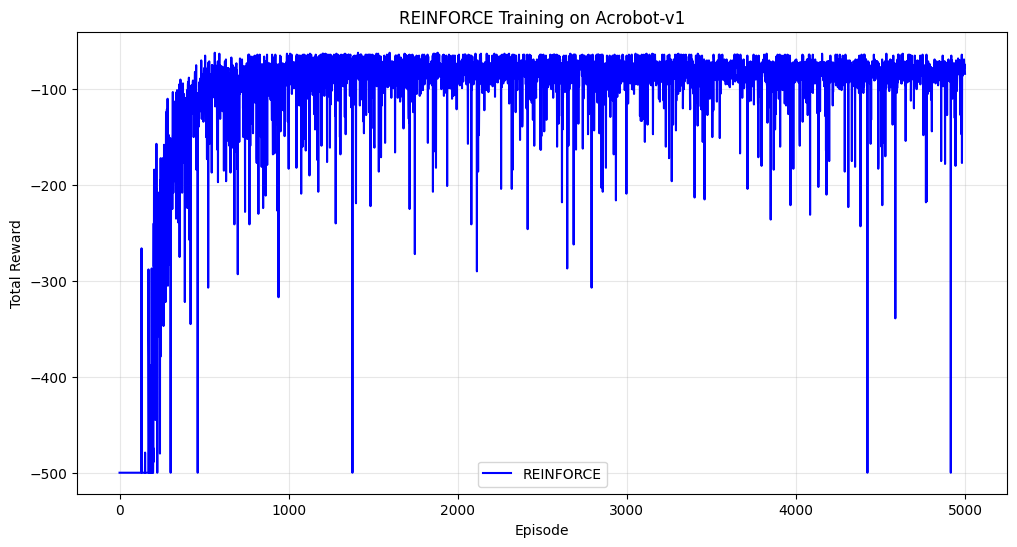

In [16]:
plot_mcr_0 = RLPlotter(mcr_trainer.model_name, montecarlo.ENV_NAME, mcr_rewards)
plot_mcr_0.plot()

In [18]:
del montecarlo

##### 1.4.2. Monte Carlo REINFORCE with Mean/Std Normalized Baseline

> Custom Initialization

In [5]:
montecarlo = replace(config, LEARNING_RATE=3e-4, MONTECARLO_BASELINE_OPT=1)

> Training

In [6]:
mcr_agent = REINFORCEAgent(env.single_observation_space.shape[0], env.single_action_space.n, montecarlo)
mcr_trainer = PolicyTrainer(env, mcr_agent, montecarlo)
mcr_rewards = mcr_trainer.train()
mcr_trainer.save_checkpoint(filepath="../models/checkpoints/Acrobot/mcr_meanNorm_checkpoint.pth")

Starting Vectorized REINFORCE Training on Acrobot-v1...


100%|██████████| 5000/5000 [08:40<00:00,  9.61it/s]

Policy-Based Training completed!
Model successfully saved to ../models/checkpoints/Acrobot/mcr_meanNorm_checkpoint.pth


> Plots

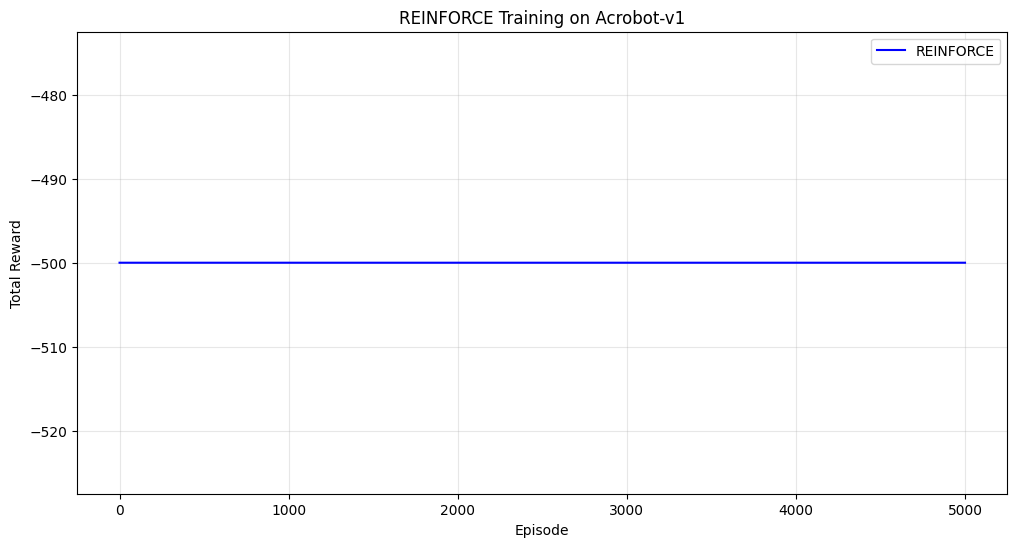

In [7]:
plot_mcr_1 = RLPlotter(mcr_trainer.model_name, montecarlo.ENV_NAME, mcr_rewards)
plot_mcr_1.plot()

In [8]:
del montecarlo

##### 1.4.3. Monte Carlo REINFORCE with Critic Baseline

> Custom Initialization

In [9]:
montecarlo = replace(config, LEARNING_RATE=3e-4, MONTECARLO_BASELINE_OPT=2)

> Training

In [10]:
mcr = REINFORCEAgent(env.single_observation_space.shape[0], env.single_action_space.n, montecarlo)
mcr_trainer = PolicyTrainer(env, mcr, montecarlo)
mcr_rewards = mcr_trainer.train()
mcr_trainer.save_checkpoint(filepath="../models/checkpoints/Acrobot/mcr_critic_checkpoint.pth")

Starting Vectorized REINFORCE Training on Acrobot-v1...


100%|██████████| 5000/5000 [02:30<00:00, 33.20it/s]

Policy-Based Training completed!
Model successfully saved to ../models/checkpoints/Acrobot/mcr_critic_checkpoint.pth


> Plots

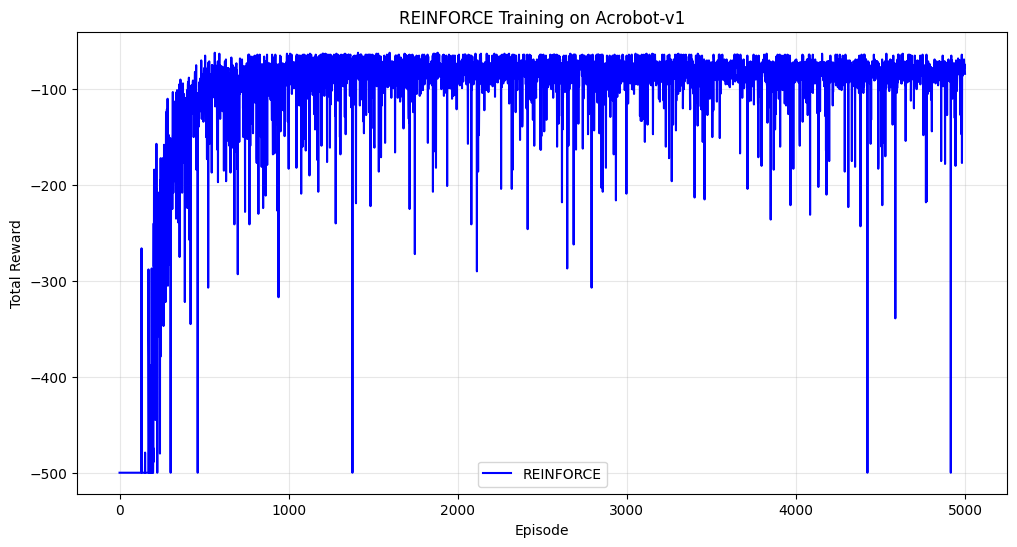

In [11]:
plot_mcr_2 = RLPlotter(mcr_trainer.model_name, montecarlo.ENV_NAME, mcr_rewards)
plot_mcr_2.plot()

In [12]:
del montecarlo

#### 1.5. Comparative plot

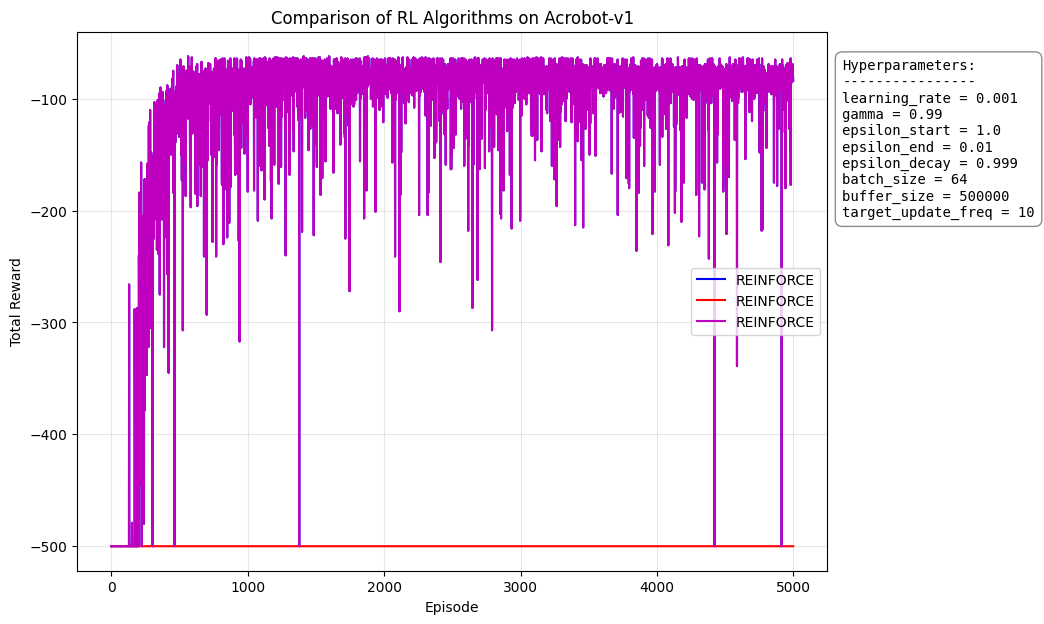

In [19]:
hyperparams = {
    "learning_rate": config.LEARNING_RATE,
    "gamma": config.GAMMA,
    "epsilon_start": config.EPSILON_START,
    "epsilon_end": config.EPSILON_END,
    "epsilon_decay": config.EPSILON_DECAY,
    "batch_size": config.BATCH_SIZE,
    "buffer_size": config.BUFFER_SIZE,
    "target_update_freq": config.TARGET_UPDATE_FREQ
}

RLPlotter.compare([plot_mcr_0, plot_mcr_1, plot_mcr_2], global_title="Comparison of RL Algorithms on Acrobot-v1", hyperparameters=hyperparams, show=True)

### 2. CartPole

>**Initializations**

In [20]:
# Shared environment setup
config = RLConfig(ENV_NAME="CartPole-v1", EPISODES=1000, STEP_BASED_TARGET_UPDATE_FREQ=5000)
env = gym.make_vec(config.ENV_NAME, num_envs=config.NUM_ENVS)

# Common Values
buffer_size = [5000, 10000, 100000, 500000]
hyperparams = {
    "learning_rate": config.LEARNING_RATE,
    "gamma": config.GAMMA,
    "epsilon_start": config.EPSILON_START,
    "epsilon_end": config.EPSILON_END,
    "epsilon_decay": config.EPSILON_DECAY,
    "batch_size": config.BATCH_SIZE,
    "buffer_size": config.BUFFER_SIZE,
    "target_update_freq": config.TARGET_UPDATE_FREQ
}

#### 2.1. DQN


Standard DQN on CartPole

Starting Vectorized DQN Training on CartPole-v1...


  0%|          | 0/1000 [00:00<?, ?it/s]d:\Projects\RL Analytics\Notebooks\..\utils.py:29: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  return torch.tensor(states), torch.tensor(actions), torch.tensor(rewards), torch.tensor(next_states), torch.tensor(done)
100%|██████████| 1000/1000 [03:53<00:00,  4.29it/s]

DQN Training completed!


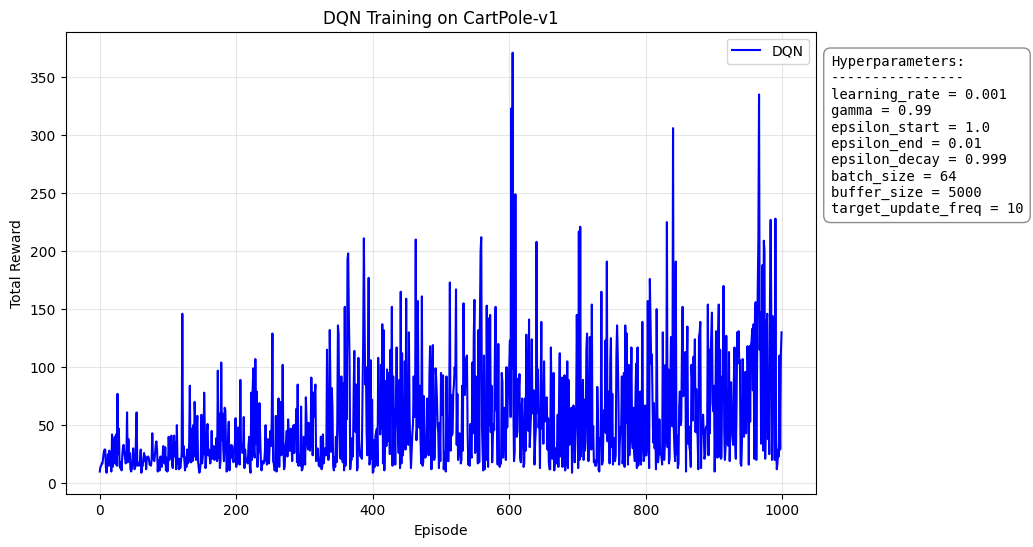

Starting Vectorized DQN Training on CartPole-v1...


1001it [03:40,  4.54it/s]                          

DQN Training completed!


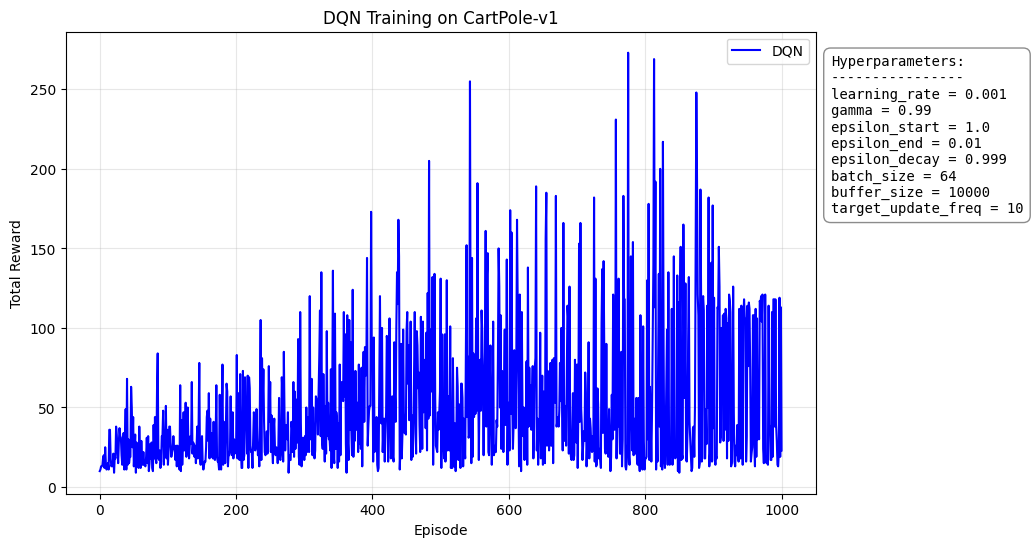

Starting Vectorized DQN Training on CartPole-v1...


100%|██████████| 1000/1000 [03:50<00:00,  4.35it/s]

DQN Training completed!


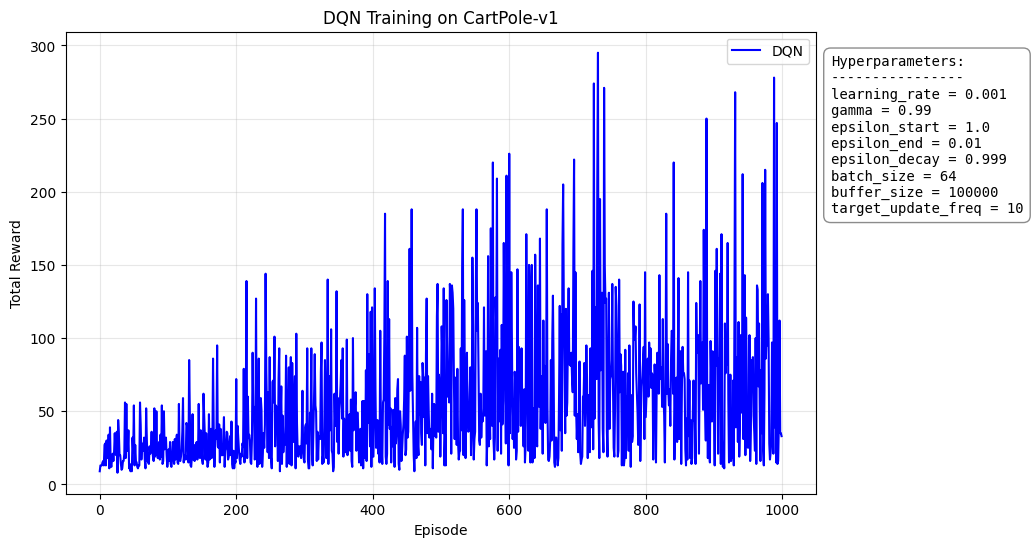

Starting Vectorized DQN Training on CartPole-v1...


100%|██████████| 1000/1000 [04:05<00:00,  4.07it/s]

DQN Training completed!


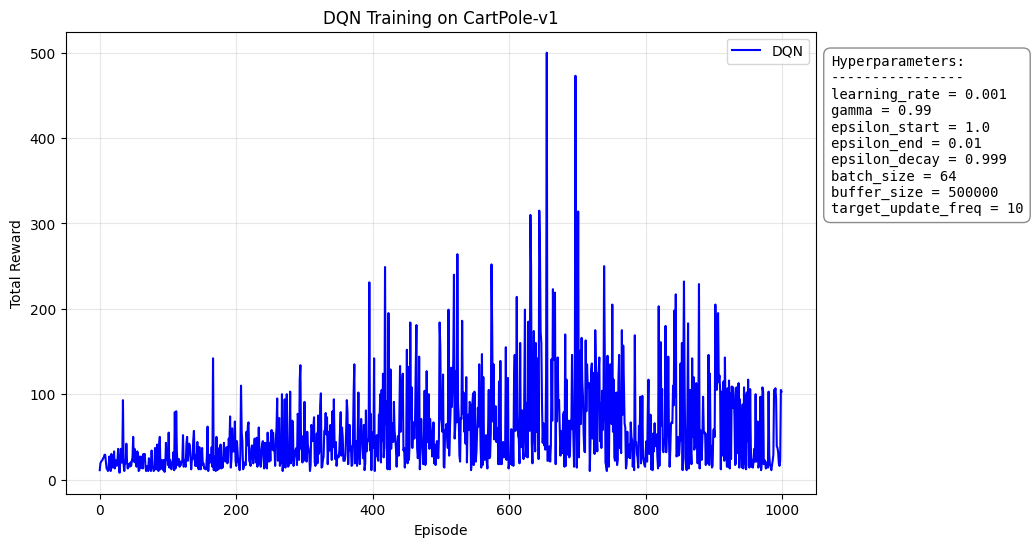

In [21]:
for i in range(len(buffer_size)):
    # Setting Buffer Size
    testing_config = replace(config, BUFFER_SIZE=buffer_size[i])
    hyperparams["buffer_size"] = buffer_size[i]
    
    # Training Loop
    dqn_agent = DQNAgent(env.single_observation_space.shape[0], env.single_action_space.n, testing_config)
    dqn_trainer = ValueTrainer(env, dqn_agent, testing_config)
    dqn_rewards = dqn_trainer.train()
    
    # Plots
    plot_dqn = RLPlotter(dqn_trainer.model_name, config.ENV_NAME, dqn_rewards)
    plot_dqn.plot(hyperparameters=hyperparams, show=True)

#### 2.2. DDQN


Standard DDQN on CartPole

Starting Vectorized DDQN Training on CartPole-v1...


100%|██████████| 1000/1000 [03:35<00:00,  4.65it/s]

DDQN Training completed!


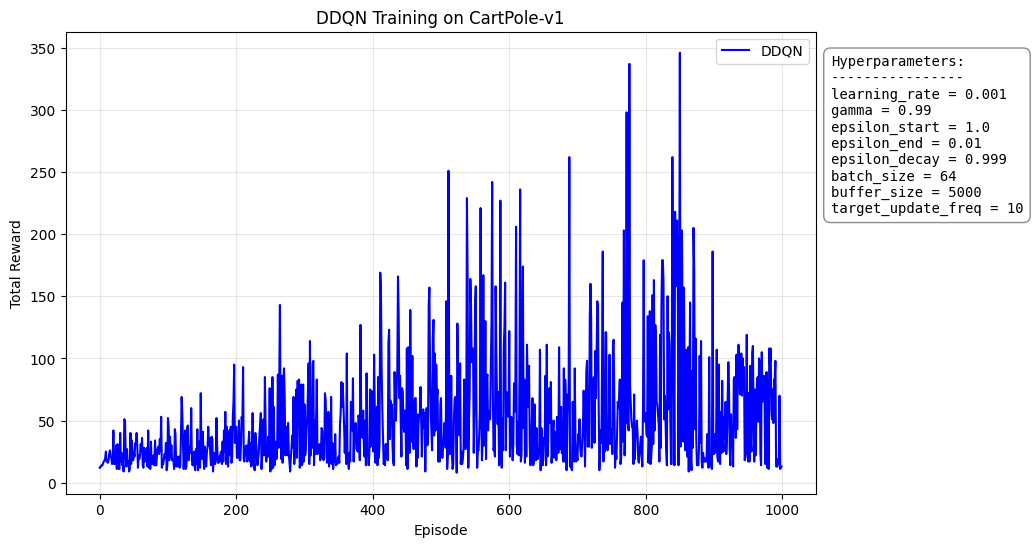

Starting Vectorized DDQN Training on CartPole-v1...


100%|██████████| 1000/1000 [04:13<00:00,  3.94it/s]

DDQN Training completed!


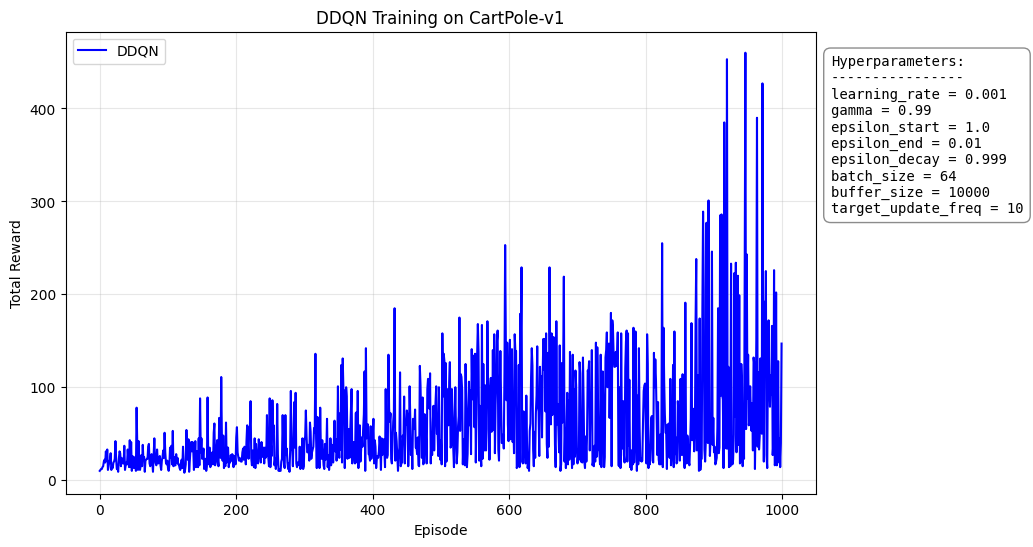

Starting Vectorized DDQN Training on CartPole-v1...


100%|██████████| 1000/1000 [04:21<00:00,  3.83it/s]

DDQN Training completed!


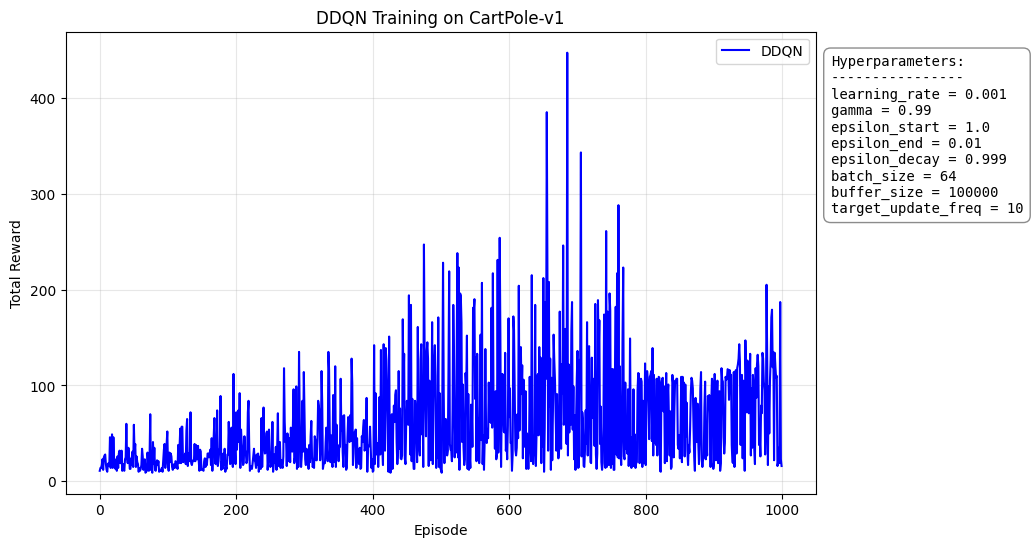

Starting Vectorized DDQN Training on CartPole-v1...


100%|██████████| 1000/1000 [03:20<00:00,  4.98it/s]

DDQN Training completed!


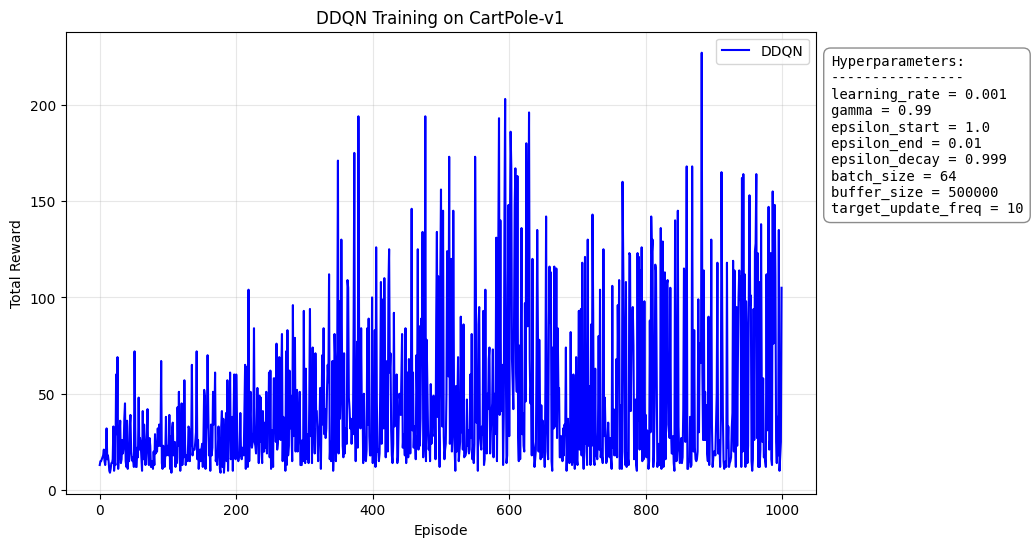

In [22]:
for i in range(len(buffer_size)):
    # Setting Buffer Size
    testing_config = replace(config, BUFFER_SIZE=buffer_size[i])
    hyperparams["buffer_size"] = buffer_size[i]
    
    # Training Loop
    ddqn_agent = DDQNAgent(env.single_observation_space.shape[0], env.single_action_space.n, testing_config)
    ddqn_trainer = ValueTrainer(env, ddqn_agent, testing_config)
    ddqn_rewards = ddqn_trainer.train()
    
    # Plots
    plot_ddqn = RLPlotter(ddqn_trainer.model_name, config.ENV_NAME, ddqn_rewards)
    plot_ddqn.plot(hyperparameters=hyperparams, show=True)

#### 2.3. Dueling DDQN


Two Implementations: Mean Normalized Advantage and Max Normalized Advantage

##### 2.3.1. Dueling DDQN with Mean Normalized Advantage

Starting Vectorized DuelingDQN Training on CartPole-v1...


100%|██████████| 1000/1000 [14:22<00:00,  1.16it/s]


DuelingDQN Training completed!
Model successfully saved to ../models/checkpoints/CartPole/dueling_mean_checkpoint.pth


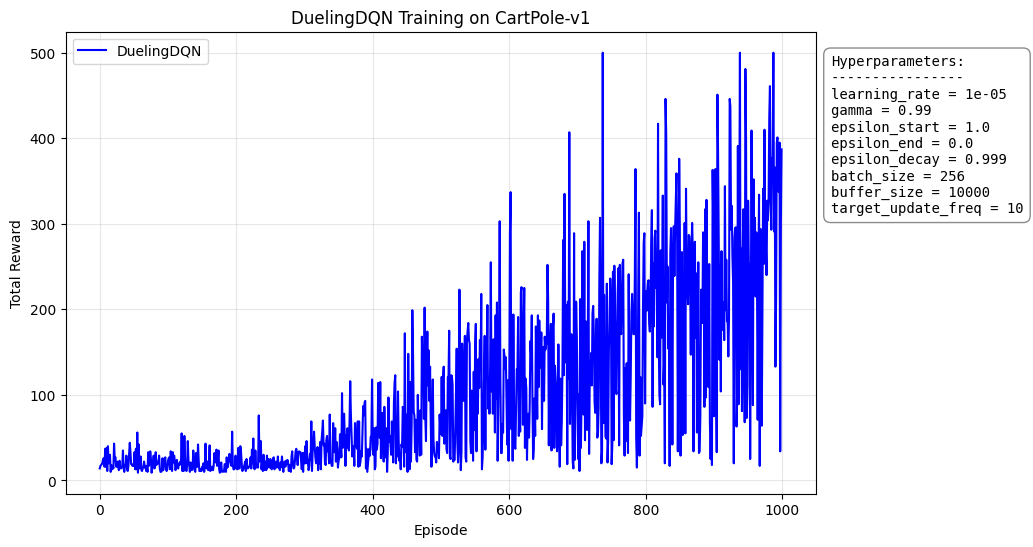

In [23]:
dueling_config = replace(config, BUFFER_SIZE=10000, LEARNING_RATE=1e-5, BATCH_SIZE=256, EPSILON_END=0.0, DUELING_OPT=0)

dueling_agent = DuelingDQNAgent(env.single_observation_space.shape[0], env.single_action_space.n, dueling_config)
dueling_trainer = ValueTrainer(env, dueling_agent, dueling_config)
dueling_rewards = dueling_trainer.train()
dueling_trainer.save_checkpoint(filepath="../models/checkpoints/CartPole/dueling_mean_checkpoint.pth")

hyperparams["learning_rate"] = dueling_config.LEARNING_RATE
hyperparams["batch_size"] = dueling_config.BATCH_SIZE
hyperparams["buffer_size"] = dueling_config.BUFFER_SIZE
hyperparams["epsilon_end"] = dueling_config.EPSILON_END

plot_dueling_mean = RLPlotter(dueling_trainer.model_name, dueling_config.ENV_NAME, dueling_rewards)
plot_dueling_mean.plot(hyperparameters=hyperparams, show=True)

##### 2.3.2. Dueling DDQN with Max Normalized Advantage

Starting Vectorized DuelingDQN Training on CartPole-v1...


100%|██████████| 1000/1000 [13:30<00:00,  1.23it/s]

DuelingDQN Training completed!
Model successfully saved to ../models/checkpoints/CartPole/dueling_max_checkpoint.pth


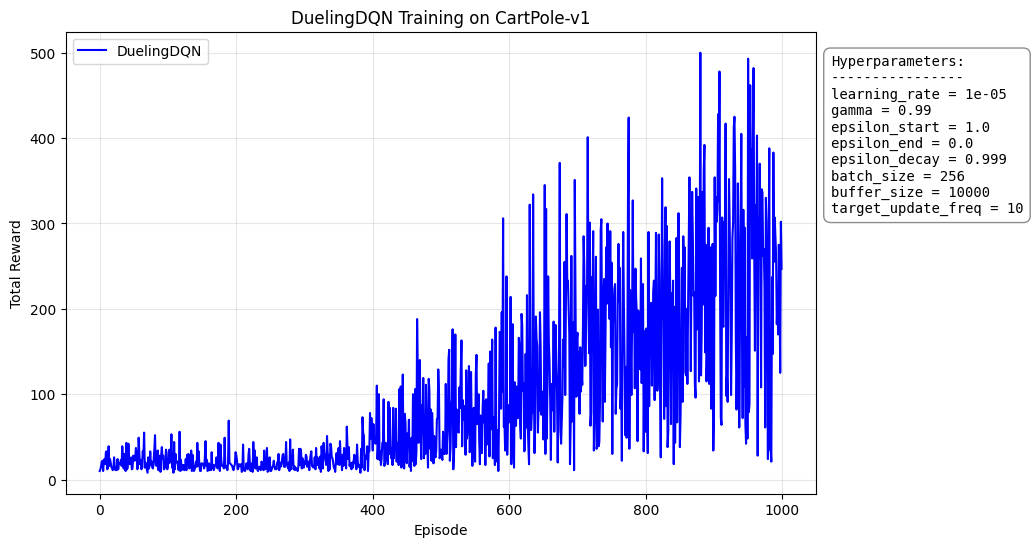

In [24]:
dueling_config = replace(config, BUFFER_SIZE=10000, LEARNING_RATE=1e-5, BATCH_SIZE=256, EPSILON_END=0.0, DUELING_OPT=1)

dueling_agent = DuelingDQNAgent(env.single_observation_space.shape[0], env.single_action_space.n, dueling_config)
dueling_trainer = ValueTrainer(env, dueling_agent, dueling_config)
dueling_rewards = dueling_trainer.train()
dueling_trainer.save_checkpoint(filepath="../models/checkpoints/CartPole/dueling_max_checkpoint.pth")

hyperparams["learning_rate"] = dueling_config.LEARNING_RATE
hyperparams["batch_size"] = dueling_config.BATCH_SIZE
hyperparams["buffer_size"] = dueling_config.BUFFER_SIZE
hyperparams["epsilon_end"] = dueling_config.EPSILON_END

plot_dueling_max = RLPlotter(dueling_trainer.model_name, dueling_config.ENV_NAME, dueling_rewards)
plot_dueling_max.plot(hyperparameters=hyperparams, show=True)

#### 2.4. Monte Carlo REINFORCE

Three Implementations:

1. No Baseline
2. Episodic Mean/std Normalized Baseline
3. Critic network baseline

##### 2.4.1. Monte Carlo REINFORCE with No Baseline

Starting Vectorized REINFORCE Training on CartPole-v1...


100%|██████████| 1000/1000 [00:10<00:00, 96.35it/s]


Policy-Based Training completed!


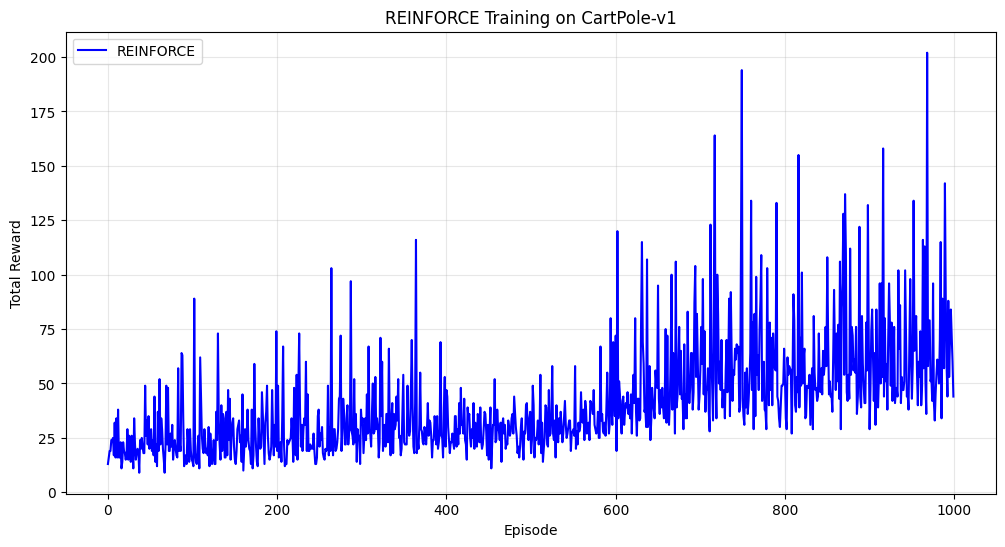

In [25]:
montecarlo = replace(config, LEARNING_RATE=3e-4, MONTECARLO_BASELINE_OPT=0)

mcr_agent = REINFORCEAgent(env.single_observation_space.shape[0], env.single_action_space.n, montecarlo)
mcr_trainer = PolicyTrainer(env, mcr_agent, montecarlo)
mcr_rewards = mcr_trainer.train()

plot_mcr_0 = RLPlotter(mcr_trainer.model_name, montecarlo.ENV_NAME, mcr_rewards)
plot_mcr_0.plot()

##### 2.4.2. Monte Carlo REINFORCE with Mean/Std Normalized Baseline

Starting Vectorized REINFORCE Training on CartPole-v1...


100%|██████████| 1000/1000 [00:26<00:00, 37.65it/s]

Policy-Based Training completed!


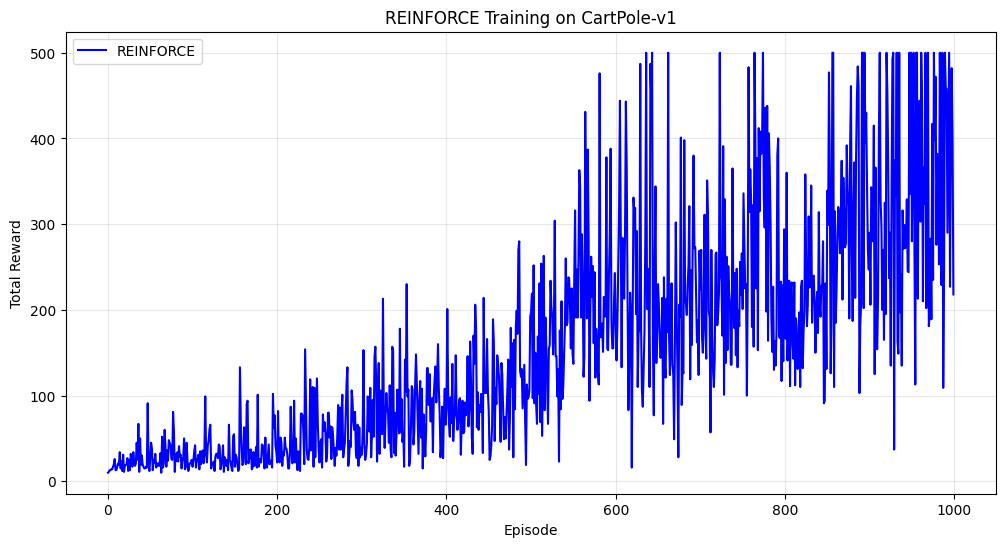

In [26]:
montecarlo = replace(config, LEARNING_RATE=3e-4, MONTECARLO_BASELINE_OPT=1)

mcr_agent = REINFORCEAgent(env.single_observation_space.shape[0], env.single_action_space.n, montecarlo)
mcr_trainer = PolicyTrainer(env, mcr_agent, montecarlo)
mcr_rewards = mcr_trainer.train()

plot_mcr_1 = RLPlotter(mcr_trainer.model_name, montecarlo.ENV_NAME, mcr_rewards)
plot_mcr_1.plot()

##### 2.4.3. Monte Carlo REINFORCE with Critic Baseline

Starting Vectorized REINFORCE Training on CartPole-v1...


1001it [00:11, 85.22it/s]                         


Policy-Based Training completed!


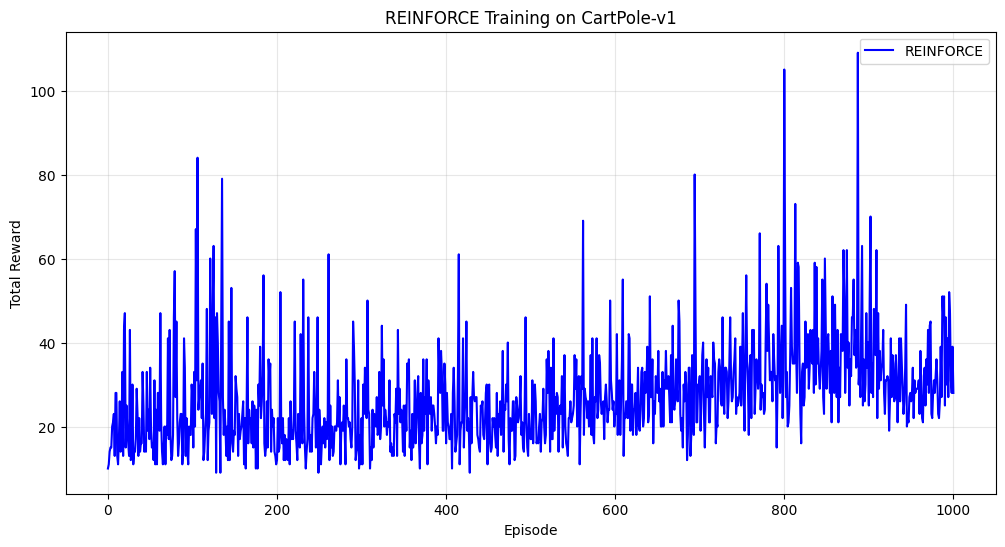

In [27]:
montecarlo = replace(config, LEARNING_RATE=3e-4, CRITIC_LR=1e-6,MONTECARLO_BASELINE_OPT=2)

mcr_agent = REINFORCEAgent(env.single_observation_space.shape[0], env.single_action_space.n, montecarlo)
mcr_trainer = PolicyTrainer(env, mcr_agent, montecarlo)
mcr_rewards = mcr_trainer.train()

plot_mcr_2 = RLPlotter(mcr_trainer.model_name, montecarlo.ENV_NAME, mcr_rewards)
plot_mcr_2.plot()

#### 2.5. Comparative plots

FileNotFoundError: [Errno 2] No such file or directory: '../plots/CartPole/comparison_plot.png'

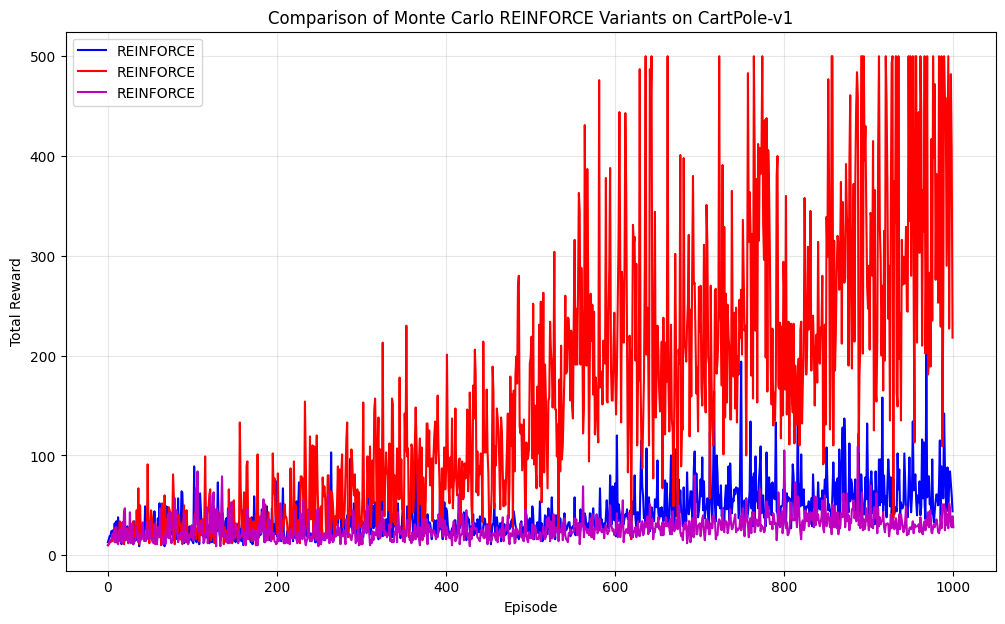

In [28]:
# Only for Monte Carlo REINFORCE methods
RLPlotter.compare([plot_mcr_0, plot_mcr_1, plot_mcr_2], global_title="Comparison of Monte Carlo REINFORCE Variants on CartPole-v1", show=True, save_path="../plots/CartPole/comparison_plot.png")